# Predicting the 2026 World Cup
Objective: predict not just the winner but scoreline of each individual game at the WC.

## Step 1: data cleaning

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from PIL.ImageChops import difference

# useful vars
# The 48 teams in the 2026 World Cup (names match results.csv exactly).
WC_2026_TEAMS = [
    'Algeria', 'Argentina', 'Australia', 'Austria', 'Belgium',
    'Bosnia and Herzegovina', 'Brazil', 'Canada', 'Cape Verde', 'Colombia',
    'Croatia', 'Curaçao', 'Czech Republic', 'DR Congo', 'Ecuador',
    'Egypt', 'England', 'France', 'Germany', 'Ghana',
    'Haiti', 'Iran', 'Iraq', 'Ivory Coast', 'Japan',
    'Jordan', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand',
    'Norway', 'Panama', 'Paraguay', 'Portugal', 'Qatar',
    'Saudi Arabia', 'Scotland', 'Senegal', 'South Africa', 'South Korea',
    'Spain', 'Sweden', 'Switzerland', 'Tunisia', 'Turkey',
    'United States', 'Uruguay', 'Uzbekistan',
]

df = pd.read_csv('results.csv')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


### Cleaning results

In [2]:
from datetime import date, datetime

# clean data
df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")

try:
    df.drop(columns=['city', 'country'], inplace=True)
except:
    print("No city found")
df['home_score'] = pd.to_numeric(df['home_score'], errors='coerce').astype('Int64')
df['away_score'] = pd.to_numeric(df['away_score'], errors='coerce').astype('Int64')
df.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,False
1,1873-03-08,England,Scotland,4,2,Friendly,False
2,1874-03-07,Scotland,England,2,1,Friendly,False
3,1875-03-06,England,Scotland,2,2,Friendly,False
4,1876-03-04,Scotland,England,3,0,Friendly,False


### Calculating ELO

In [3]:
# --- ELO helpers ---------------------------------------------------------

def k_factor(tournament: str) -> float:
    """ELO weight by match importance (modeled on eloratings.net)."""
    t = tournament.lower()
    if 'world cup' in t and 'qualif' not in t:
        return 60.0
    if t in {'copa america', 'uefa euro', 'african cup of nations', 'afc asian cup'}:
        return 50.0
    if 'qualif' in t or 'nations league' in t:
        return 40.0
    if t == 'friendly':
        return 20.0
    return 30.0


def g_multiplier(goal_diff: int) -> float:
    """Goal-difference multiplier — bigger wins move ELO more."""
    gd = abs(goal_diff)
    if gd <= 1:
        return 1.0
    if gd == 2:
        return 1.5
    return (11 + gd) / 8.0


def expected_score(r_home: float, r_away: float, home_adv: float = 100.0) -> float:
    """Probability the home team takes the points (draw counts as 0.5)."""
    return 1.0 / (1.0 + 10.0 ** (-(r_home - r_away + home_adv) / 400.0))


def update_match(r_home, r_away, home_score, away_score, tournament, neutral):
    """Apply one match. Returns the new (home_rating, away_rating)."""
    h = 0.0 if neutral else 100.0
    exp_home = expected_score(r_home, r_away, h)

    if home_score > away_score:
        w_home = 1.0
    elif home_score < away_score:
        w_home = 0.0
    else:
        w_home = 0.5

    k = k_factor(tournament) * g_multiplier(home_score - away_score)
    delta = k * (w_home - exp_home)
    return r_home + delta, r_away - delta


def compute_elo_history(matches: pd.DataFrame, initial_rating: float = 1500.0):
    """Walk matches in date order; stamp each row with pre-match ELO for both teams.

    Returns (df_with_elo, final_ratings_dict). Run over the FULL history
    (not a recent slice) so ratings have time to separate teams.
    """
    matches = matches.sort_values('date', kind='mergesort').reset_index(drop=True)
    ratings: dict[str, float] = {}
    elo_home_pre = np.empty(len(matches))
    elo_away_pre = np.empty(len(matches))

    for i, row in enumerate(matches.itertuples(index=False)):
        home, away = row.home_team, row.away_team
        r_home = ratings.get(home, initial_rating)
        r_away = ratings.get(away, initial_rating)
        elo_home_pre[i] = r_home
        elo_away_pre[i] = r_away

        if pd.isna(row.home_score) or pd.isna(row.away_score):
            continue

        ratings[home], ratings[away] = update_match(
            r_home, r_away,
            int(row.home_score), int(row.away_score),
            row.tournament, bool(row.neutral),
        )

    matches = matches.copy()
    matches['elo_home_pre'] = elo_home_pre
    matches['elo_away_pre'] = elo_away_pre
    return matches, ratings


# --- run over full history, then slice to modeling window ----------------

df, final_ratings = compute_elo_history(df)
# adjust before or after elo, that is the question
df = df[df['date'] > pd.Timestamp("2020-12-31")]

# sanity check: top teams should look roughly sensible
pd.Series(final_ratings).sort_values(ascending=False).head(15)


Spain          2212.508845
Argentina      2168.814153
France         2118.570970
England        2082.359234
Brazil         2063.005074
Colombia       2042.200938
Portugal       2037.689031
Ecuador        2017.082540
Netherlands    2000.655570
Germany        2000.202876
Japan          1990.407273
Morocco        1983.590878
Uruguay        1968.084275
Norway         1967.563905
Turkey         1965.366679
dtype: float64

In [4]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,neutral,elo_home_pre,elo_away_pre
43722,2021-01-12,United Arab Emirates,Iraq,0,0,Friendly,False,1560.619013,1735.725996
43723,2021-01-18,Kuwait,Palestine,0,1,Friendly,False,1515.841244,1507.549035
43724,2021-01-19,Dominican Republic,Puerto Rico,0,1,Friendly,False,1387.026266,1195.808819
43725,2021-01-22,Guatemala,Puerto Rico,1,0,Friendly,False,1618.584779,1212.657317
43726,2021-01-25,Dominican Republic,Serbia,0,0,Friendly,False,1370.177768,1828.984250


### Calculating recent Goals for and goals against

In [5]:
from collections import deque

def compute_recent_goals(matches: pd.DataFrame):
    """Walk matches in date order; stamp each row with last-10-games
    goals-for and goals-against, NORMALISED against opponent ELO.

    A team that scores 3 a game against minnows looks identical to one
    that scores 3 a game against top-10 sides if you just use raw totals.
    To fix that, we fit a league-wide baseline `expected_goals_scored =
    a + b*opp_elo` and store (actual - expected) per game. The recent
    stat is then the mean residual over the last 10 games:
        > 0 → out-scoring what an avg team would manage vs those opponents
        < 0 → underperforming for the matchups faced
    Same logic on the GA side; by symmetry the same baseline covers both
    (goals conceded by team = goals scored by opp, and opp's `opp_elo`
    from their POV is this team's elo).
    """
    recent = 10
    matches = matches.sort_values('date', kind='mergesort').reset_index(drop=True)

    # Fit baseline on completed matches; each match yields two observations
    # (one per side), so the fit sees a symmetric (opp_elo, scored) sample.
    played = matches.dropna(subset=['home_score', 'away_score'])
    opp_elo = np.concatenate([played['elo_away_pre'].values,
                              played['elo_home_pre'].values])
    scored = np.concatenate([played['home_score'].astype(float).values,
                             played['away_score'].astype(float).values])
    b, a = np.polyfit(opp_elo, scored, 1)
    print(f"baseline: expected_goals_scored = {a:.3f} + {b:.6f} * opp_elo")

    # Vectorised per-row expectations — pull from these inside the loop.
    exp_home_scored = a + b * matches['elo_away_pre'].values  # home's expected GF
    exp_away_scored = a + b * matches['elo_home_pre'].values  # away's expected GF
    # By construction: home's expected GA == exp_away_scored, and vice versa.

    history: dict[str, deque] = {}
    gf_home_recent = np.empty(len(matches))
    ga_home_recent = np.empty(len(matches))
    gf_away_recent = np.empty(len(matches))
    ga_away_recent = np.empty(len(matches))

    for i, row in enumerate(matches.itertuples(index=False)):
        home, away = row.home_team, row.away_team
        dq_home = history.setdefault(home, deque(maxlen=recent))
        dq_away = history.setdefault(away, deque(maxlen=recent))

        gf_home_recent[i], ga_home_recent[i] = mean_resid(dq_home)
        gf_away_recent[i], ga_away_recent[i] = mean_resid(dq_away)

        if pd.isna(row.home_score) or pd.isna(row.away_score):
            continue

        dq_home.append((
            float(row.home_score) - exp_home_scored[i],
            float(row.away_score) - exp_away_scored[i],
        ))
        dq_away.append((
            float(row.away_score) - exp_away_scored[i],
            float(row.home_score) - exp_home_scored[i],
        ))

    matches = matches.copy()
    matches['gf_home_recent'] = gf_home_recent
    matches['ga_home_recent'] = ga_home_recent
    matches['gf_away_recent'] = gf_away_recent
    matches['ga_away_recent'] = ga_away_recent
    return matches


def mean_resid(dq):
    """Mean (gf_residual, ga_residual) over a team's last-N games. Empty → 0."""
    if not dq:
        return 0.0, 0.0
    n = len(dq)
    gf = sum(g for g, _ in dq) / n
    ga = sum(c for _, c in dq) / n
    return gf, ga


df = compute_recent_goals(df)
df[['date', 'home_team', 'away_team', 'home_score', 'away_score',
    'gf_home_recent', 'ga_home_recent', 'gf_away_recent', 'ga_away_recent']].tail(10)


baseline: expected_goals_scored = 3.798 + -0.001535 * opp_elo


,date,home_team,away_team,home_score,away_score,gf_home_recent,ga_home_recent,gf_away_recent,ga_away_recent
5705,2026-06-26,Cape Verde,Saudi Arabia,<NA>,<NA>,0.253474,-0.048515,0.036459,0.324294
5706,2026-06-26,Uruguay,Spain,<NA>,<NA>,0.012304,0.138714,1.624825,0.125060
5707,2026-06-26,Norway,France,<NA>,<NA>,1.900593,-0.129901,1.313557,0.250027
5708,2026-06-26,Senegal,Iraq,<NA>,<NA>,0.681862,0.055833,-0.112074,-0.344586
5709,2026-06-27,Algeria,Austria,<NA>,<NA>,0.753577,-0.555825,1.163035,-0.496535
5710,2026-06-27,Jordan,Argentina,<NA>,<NA>,0.801913,0.505477,1.112163,-0.159355
5711,2026-06-27,Colombia,Portugal,<NA>,<NA>,1.533448,0.429634,1.488832,0.361349
5712,2026-06-27,DR Congo,Uzbekistan,<NA>,<NA>,-0.145246,-0.824198,0.134773,-0.292393
5713,2026-06-27,Panama,England,<NA>,<NA>,0.600681,0.630414,1.048415,-0.109813
5714,2026-06-27,Croatia,Ghana,<NA>,<NA>,0.945808,0.241785,-0.048037,0.084148


### Calculating recent wins/draws/loses

In [6]:
def compute_recent_wdl(matches: pd.DataFrame):
    recent_games = 5
    matches = matches.sort_values('date', kind='mergesort').reset_index(drop=True)
    recent_wdl: dict[str, deque(maxlen=recent_games)] = {}

    wdl_home_recent = np.empty(len(matches))
    wdl_away_recent = np.empty(len(matches))

    for i, row in enumerate(matches.itertuples(index=False)):
        home, away = row.home_team, row.away_team
        wdl_home = recent_wdl.setdefault(home, deque(maxlen=recent_games))
        wdl_away = recent_wdl.setdefault(away, deque(maxlen=recent_games))

        wdl_home_recent[i] = calc_wdl(wdl_home)
        wdl_away_recent[i] = calc_wdl(wdl_away)

        if pd.isna(row.home_score) or pd.isna(row.away_score):
            continue

        wdl_home.append((row.home_score, row.away_score))
        wdl_away.append((row.away_score, row.home_score))

    matches = matches.copy()
    matches['wdl_home_recent'] = wdl_home_recent
    matches['wdl_away_recent'] = wdl_away_recent
    return matches

def calc_wdl(wdl_team):
    wdl = 0
    for match in wdl_team:
        if match[0] > match[1]:
            wdl += 3
        elif match[0] == match[1]:
            wdl += 1
    return wdl

df = compute_recent_wdl(df)
df.tail(10)


,date,home_team,away_team,home_score,away_score,tournament,neutral,elo_home_pre,elo_away_pre,gf_home_recent,ga_home_recent,gf_away_recent,ga_away_recent,wdl_home_recent,wdl_away_recent
5705,2026-06-26,Cape Verde,Saudi Arabia,<NA>,<NA>,FIFA World Cup,True,1652.554072,1690.487172,0.253474,-0.048515,0.036459,0.324294,5.0,3.0
5706,2026-06-26,Uruguay,Spain,<NA>,<NA>,FIFA World Cup,True,1968.084275,2212.508845,0.012304,0.138714,1.624825,0.125060,6.0,9.0
5707,2026-06-26,Norway,France,<NA>,<NA>,FIFA World Cup,True,1967.563905,2118.570970,1.900593,-0.129901,1.313557,0.250027,10.0,12.0
5708,2026-06-26,Senegal,Iraq,<NA>,<NA>,FIFA World Cup,True,1918.182608,1749.418812,0.681862,0.055833,-0.112074,-0.344586,9.0,7.0
5709,2026-06-27,Algeria,Austria,<NA>,<NA>,FIFA World Cup,True,1871.678618,1886.563873,0.753577,-0.555825,1.163035,-0.496535,10.0,13.0
5710,2026-06-27,Jordan,Argentina,<NA>,<NA>,FIFA World Cup,True,1779.060631,2168.814153,0.801913,0.505477,1.112163,-0.159355,5.0,15.0
5711,2026-06-27,Colombia,Portugal,<NA>,<NA>,FIFA World Cup,True,2042.200938,2037.689031,1.533448,0.429634,1.488832,0.361349,9.0,10.0
5712,2026-06-27,DR Congo,Uzbekistan,<NA>,<NA>,FIFA World Cup,True,1772.992934,1823.438546,-0.145246,-0.824198,0.134773,-0.292393,10.0,6.0
5713,2026-06-27,Panama,England,<NA>,<NA>,FIFA World Cup,True,1836.620514,2082.359234,0.600681,0.630414,1.048415,-0.109813,8.0,10.0
5714,2026-06-27,Croatia,Ghana,<NA>,<NA>,FIFA World Cup,True,1961.718591,1624.448322,0.945808,0.241785,-0.048037,0.084148,9.0,1.0


### Calculate rest days before game

In [7]:
def compute_rest_days(matches: pd.DataFrame):
    """Walk matches in date order; stamp each row with days since each team's
    previous international match. NaN for a team's first appearance."""
    matches = matches.sort_values('date', kind='mergesort').reset_index(drop=True)
    last_match: dict[str, pd.Timestamp] = {}
    rest_home = np.full(len(matches), np.nan)
    rest_away = np.full(len(matches), np.nan)

    for i, row in enumerate(matches.itertuples(index=False)):
        home, away = row.home_team, row.away_team
        if home in last_match:
            rest_home[i] = (row.date - last_match[home]).days
        if away in last_match:
            rest_away[i] = (row.date - last_match[away]).days

        # stamp first, then update — feature is pre-match
        last_match[home] = row.date
        last_match[away] = row.date

    matches = matches.copy()
    matches['rest_home'] = rest_home
    matches['rest_away'] = rest_away
    return matches


df = compute_rest_days(df)
df[['date', 'home_team', 'away_team', 'rest_home', 'rest_away']].tail(10)


,date,home_team,away_team,rest_home,rest_away
5705,2026-06-26,Cape Verde,Saudi Arabia,5.0,5.0
5706,2026-06-26,Uruguay,Spain,5.0,5.0
5707,2026-06-26,Norway,France,4.0,4.0
5708,2026-06-26,Senegal,Iraq,4.0,4.0
5709,2026-06-27,Algeria,Austria,5.0,5.0
5710,2026-06-27,Jordan,Argentina,5.0,5.0
5711,2026-06-27,Colombia,Portugal,4.0,4.0
5712,2026-06-27,DR Congo,Uzbekistan,4.0,4.0
5713,2026-06-27,Panama,England,4.0,4.0
5714,2026-06-27,Croatia,Ghana,4.0,4.0


### Calculate Host Continent Advantage

In [8]:
# Host-continent advantage: flag whether each team is from the same
# confederation as the country hosting the match. The `country` column
# was dropped earlier, so re-merge it from the raw CSV just for this.

_country_df = pd.read_csv('results.csv', usecols=['date', 'home_team', 'away_team', 'country'])
_country_df['date'] = pd.to_datetime(_country_df['date'], format='%Y-%m-%d')
df = df.merge(_country_df, on=['date', 'home_team', 'away_team'], how='left')

CONTINENT = {
    # UEFA
    'Albania': 'EU', 'Andorra': 'EU', 'Armenia': 'EU', 'Austria': 'EU', 'Azerbaijan': 'EU',
    'Belarus': 'EU', 'Belgium': 'EU', 'Bosnia and Herzegovina': 'EU', 'Bulgaria': 'EU',
    'Croatia': 'EU', 'Cyprus': 'EU', 'Czech Republic': 'EU', 'Czechia': 'EU', 'Denmark': 'EU',
    'England': 'EU', 'Estonia': 'EU', 'Faroe Islands': 'EU', 'Finland': 'EU', 'France': 'EU',
    'Georgia': 'EU', 'Germany': 'EU', 'Gibraltar': 'EU', 'Greece': 'EU', 'Hungary': 'EU',
    'Iceland': 'EU', 'Israel': 'EU', 'Italy': 'EU', 'Kazakhstan': 'EU', 'Kosovo': 'EU',
    'Latvia': 'EU', 'Liechtenstein': 'EU', 'Lithuania': 'EU', 'Luxembourg': 'EU', 'Malta': 'EU',
    'Moldova': 'EU', 'Montenegro': 'EU', 'Netherlands': 'EU', 'North Macedonia': 'EU',
    'Northern Ireland': 'EU', 'Norway': 'EU', 'Poland': 'EU', 'Portugal': 'EU',
    'Republic of Ireland': 'EU', 'Romania': 'EU', 'Russia': 'EU', 'San Marino': 'EU',
    'Scotland': 'EU', 'Serbia': 'EU', 'Slovakia': 'EU', 'Slovenia': 'EU', 'Spain': 'EU',
    'Sweden': 'EU', 'Switzerland': 'EU', 'Turkey': 'EU', 'Ukraine': 'EU', 'Wales': 'EU',
    # CONMEBOL
    'Argentina': 'SA', 'Bolivia': 'SA', 'Brazil': 'SA', 'Chile': 'SA', 'Colombia': 'SA',
    'Ecuador': 'SA', 'Paraguay': 'SA', 'Peru': 'SA', 'Uruguay': 'SA', 'Venezuela': 'SA',
    # CONCACAF
    'Antigua and Barbuda': 'NA', 'Aruba': 'NA', 'Bahamas': 'NA', 'Barbados': 'NA',
    'Belize': 'NA', 'Bermuda': 'NA', 'British Virgin Islands': 'NA', 'Canada': 'NA',
    'Cayman Islands': 'NA', 'Costa Rica': 'NA', 'Cuba': 'NA', 'Curaçao': 'NA', 'Dominica': 'NA',
    'Dominican Republic': 'NA', 'El Salvador': 'NA', 'Grenada': 'NA', 'Guatemala': 'NA',
    'Guyana': 'NA', 'Haiti': 'NA', 'Honduras': 'NA', 'Jamaica': 'NA', 'Martinique': 'NA',
    'Mexico': 'NA', 'Montserrat': 'NA', 'Nicaragua': 'NA', 'Panama': 'NA', 'Puerto Rico': 'NA',
    'Saint Kitts and Nevis': 'NA', 'Saint Lucia': 'NA',
    'Saint Vincent and the Grenadines': 'NA', 'Sint Maarten': 'NA', 'Suriname': 'NA',
    'Trinidad and Tobago': 'NA', 'Turks and Caicos Islands': 'NA', 'United States': 'NA',
    'US Virgin Islands': 'NA',
    # CAF
    'Algeria': 'AF', 'Angola': 'AF', 'Benin': 'AF', 'Botswana': 'AF', 'Burkina Faso': 'AF',
    'Burundi': 'AF', 'Cameroon': 'AF', 'Cape Verde': 'AF', 'Central African Republic': 'AF',
    'Chad': 'AF', 'Comoros': 'AF', 'Congo': 'AF', 'DR Congo': 'AF', 'Djibouti': 'AF',
    'Egypt': 'AF', 'Equatorial Guinea': 'AF', 'Eritrea': 'AF', 'Eswatini': 'AF',
    'Ethiopia': 'AF', 'Gabon': 'AF', 'Gambia': 'AF', 'Ghana': 'AF', 'Guinea': 'AF',
    'Guinea-Bissau': 'AF', 'Ivory Coast': 'AF', 'Kenya': 'AF', 'Lesotho': 'AF',
    'Liberia': 'AF', 'Libya': 'AF', 'Madagascar': 'AF', 'Malawi': 'AF', 'Mali': 'AF',
    'Mauritania': 'AF', 'Mauritius': 'AF', 'Morocco': 'AF', 'Mozambique': 'AF',
    'Namibia': 'AF', 'Niger': 'AF', 'Nigeria': 'AF', 'Rwanda': 'AF',
    'São Tomé and Príncipe': 'AF', 'Senegal': 'AF', 'Seychelles': 'AF', 'Sierra Leone': 'AF',
    'Somalia': 'AF', 'South Africa': 'AF', 'South Sudan': 'AF', 'Sudan': 'AF',
    'Tanzania': 'AF', 'Togo': 'AF', 'Tunisia': 'AF', 'Uganda': 'AF', 'Zambia': 'AF',
    'Zimbabwe': 'AF',
    # AFC (note: Australia moved from OFC to AFC in 2006)
    'Afghanistan': 'AS', 'Australia': 'AS', 'Bahrain': 'AS', 'Bangladesh': 'AS', 'Bhutan': 'AS',
    'Brunei': 'AS', 'Cambodia': 'AS', 'China PR': 'AS', 'East Timor': 'AS', 'Guam': 'AS',
    'Hong Kong': 'AS', 'India': 'AS', 'Indonesia': 'AS', 'Iran': 'AS', 'Iraq': 'AS',
    'Japan': 'AS', 'Jordan': 'AS', 'Kuwait': 'AS', 'Kyrgyzstan': 'AS', 'Laos': 'AS',
    'Lebanon': 'AS', 'Macau': 'AS', 'Malaysia': 'AS', 'Maldives': 'AS', 'Mongolia': 'AS',
    'Myanmar': 'AS', 'Nepal': 'AS', 'North Korea': 'AS', 'Oman': 'AS', 'Pakistan': 'AS',
    'Palestine': 'AS', 'Philippines': 'AS', 'Qatar': 'AS', 'Saudi Arabia': 'AS',
    'Singapore': 'AS', 'South Korea': 'AS', 'Sri Lanka': 'AS', 'Syria': 'AS',
    'Tajikistan': 'AS', 'Thailand': 'AS', 'Turkmenistan': 'AS', 'United Arab Emirates': 'AS',
    'Uzbekistan': 'AS', 'Vietnam': 'AS', 'Yemen': 'AS',
    # OFC
    'American Samoa': 'OC', 'Cook Islands': 'OC', 'Fiji': 'OC', 'New Caledonia': 'OC',
    'New Zealand': 'OC', 'Papua New Guinea': 'OC', 'Samoa': 'OC', 'Solomon Islands': 'OC',
    'Tahiti': 'OC', 'Tonga': 'OC', 'Vanuatu': 'OC',
}

host_continent = df['country'].map(CONTINENT)
home_continent = df['home_team'].map(CONTINENT)
away_continent = df['away_team'].map(CONTINENT)

df['home_in_host_continent'] = (home_continent == host_continent).astype(int)
df['away_in_host_continent'] = (away_continent == host_continent).astype(int)

# drop the temp country col — same choice we made earlier
df = df.drop(columns=['country'])

df[['date', 'home_team', 'away_team', 'neutral',
    'home_in_host_continent', 'away_in_host_continent']].tail(10)


,date,home_team,away_team,neutral,home_in_host_continent,away_in_host_continent
5707,2026-06-26,Cape Verde,Saudi Arabia,True,0,0
5708,2026-06-26,Uruguay,Spain,True,0,0
5709,2026-06-26,Norway,France,True,0,0
5710,2026-06-26,Senegal,Iraq,True,0,0
5711,2026-06-27,Algeria,Austria,True,0,0
5712,2026-06-27,Jordan,Argentina,True,0,0
5713,2026-06-27,Colombia,Portugal,True,0,0
5714,2026-06-27,DR Congo,Uzbekistan,True,0,0
5715,2026-06-27,Panama,England,True,1,0
5716,2026-06-27,Croatia,Ghana,True,0,0


### Add sofifa data

In [9]:
import re
# Sofifa uses a few non-standard names. Map them to whatever results.csv uses
# so this stats table can later be joined to df by team name.
SOFIFA_TO_CANONICAL = {
    'Czechia': 'Czech Republic',
    'Türkiye': 'Turkey',
    'Cabo Verde': 'Cape Verde',
    'Congo DR': 'DR Congo',
    "Côte d'Ivoire": 'Ivory Coast',
    'Korea Republic': 'South Korea',
    'Curacao': 'Curaçao',
}

_ROW_PATTERN = re.compile(
    r'<a href="https://sofifa\.com/team/\d+/[^/]+/\d+/">([^<]+)</a>'
    r'.*?data-col="oa".*?title="(\d+)"'
    r'.*?data-col="at".*?title="(\d+)"'
    r'.*?data-col="md".*?title="(\d+)"'
    r'.*?data-col="df".*?title="(\d+)"'
    r'.*?data-col="sa"><em>([\d.]+)</em>',
    re.DOTALL,
)

def parse_sofifa_listing(filepath: str) -> pd.DataFrame:
    """Pull team / overall / attack / midfield / defence / starting-XI age
    from a saved sofifa national-teams listing page."""
    with open(filepath, encoding='utf-8') as f:
        html = f.read()
    rows = _ROW_PATTERN.findall(html)
    out = pd.DataFrame(rows, columns=[
        'team', 'overall', 'attack', 'midfield', 'defence', 'starting_xi_avg_age'
    ])
    out['team'] = out['team'].replace(SOFIFA_TO_CANONICAL)
    for c in ['overall', 'attack', 'midfield', 'defence']:
        out[c] = pd.to_numeric(out[c])
    out['starting_xi_avg_age'] = pd.to_numeric(out['starting_xi_avg_age'])
    return out

fc25 = parse_sofifa_listing('sofifa_teams_fc25.html')
fc26 = parse_sofifa_listing('sofifa_teams_fc26.html')
print(f"FC25 parsed: {len(fc25)} teams; FC26 parsed: {len(fc26)} teams")
fc26.head()


FC25 parsed: 29 teams; FC26 parsed: 60 teams


,team,overall,attack,midfield,defence,starting_xi_avg_age
0,France,86,87,85,85,25.82
1,Spain,85,85,86,83,25.45
2,England,84,86,85,83,25.27
3,Germany,84,81,84,85,26.18
4,Portugal,84,84,86,84,27.36


In [10]:
# 2015-2024 snapshots from Stefano's CSV. league_id 78 = "Friendly International"
# (i.e. the national-team rows). FIFA version N → calendar year 2000 + N.

CSV_TO_CANONICAL = {
    'Korea Republic': 'South Korea',
}

teams_hist = pd.read_csv(
    'male_teams_14-24.csv',
    usecols=['team_name', 'fifa_version', 'league_id',
             'overall', 'attack', 'midfield', 'defence',
             'starting_xi_average_age'],
)
teams_hist = teams_hist[teams_hist['league_id'] == 78].drop(columns=['league_id'])
teams_hist['team'] = teams_hist['team_name'].replace(CSV_TO_CANONICAL)
teams_hist['year'] = 2000 + teams_hist['fifa_version'].astype(int)
teams_hist = teams_hist.rename(columns={'starting_xi_average_age': 'starting_xi_avg_age'})
teams_hist = (teams_hist[['team', 'year', 'overall', 'attack', 'midfield', 'defence',
                          'starting_xi_avg_age']]
              .drop_duplicates(subset=['team', 'year'])
              .reset_index(drop=True))
teams_hist.tail()


,team,year,overall,attack,midfield,defence,starting_xi_avg_age
431,Egypt,2015,69,70,68,67,25.45
432,Bulgaria,2015,67,66,67,66,28.18
433,Bolivia,2015,65,68,60,63,27.73
434,New Zealand,2015,64,65,59,63,24.36
435,India,2015,57,59,56,56,25.82


In [11]:
# Combine into one (team, year) table. FC25 had ~30 teams missing from the scrape —
# back-fill those with their FC24 row (best available proxy) so the 2025 slice is
# complete. FC26 is taken as-is.

fc24 = teams_hist.loc[teams_hist['year'] == 2024,
                      ['team', 'overall', 'attack', 'midfield', 'defence',
                       'starting_xi_avg_age']]

fc25_filled = pd.concat([
    fc25.assign(year=2025),
    fc24[~fc24['team'].isin(fc25['team'])].assign(year=2025),
], ignore_index=True)

fc26_yr = fc26.assign(year=2026)

team_stats = pd.concat([teams_hist, fc25_filled, fc26_yr], ignore_index=True)
team_stats = (team_stats[['team', 'year', 'overall', 'attack', 'midfield',
                          'defence', 'starting_xi_avg_age']]
              .sort_values(['team', 'year'])
              .reset_index(drop=True))

print(f"rows: {len(team_stats)} | teams: {team_stats['team'].nunique()} "
      f"| years: {team_stats['year'].min()}-{team_stats['year'].max()}")
team_stats[team_stats['team'].isin(['France', 'Brazil', 'Argentina', 'Cape Verde'])]


rows: 526 | teams: 72 | years: 2015-2026


,team,year,overall,attack,midfield,defence,starting_xi_avg_age
1,Argentina,2015,81,84,80,79,27.73
2,Argentina,2016,83,88,81,82,27.64
3,Argentina,2017,84,87,84,80,28.55
4,Argentina,2018,83,88,82,81,29.27
5,Argentina,2019,83,87,82,81,28.82
6,Argentina,2020,81,84,81,79,27.55
7,Argentina,2021,82,87,80,79,28.09
8,Argentina,2022,84,87,82,81,27.82
9,Argentina,2023,83,86,82,81,28.73
10,Argentina,2024,83,85,83,83,28.64


In [12]:
# Attach team_stats to each match using actual sofifa snapshot dates so a match
# played in (e.g.) Aug 2024 picks the FIFA 24 row, not the FC 25 row that hadn't
# released yet. 2015-2024 dates come from the CSV's update_as_of column;
# FC 25 / FC 26 use their public release dates.

SNAPSHOT_DATE = {
    2015: '2014-09-18', 2016: '2015-09-21', 2017: '2016-09-20',
    2018: '2017-09-18', 2019: '2018-08-21', 2020: '2019-09-19',
    2021: '2020-09-23', 2022: '2021-09-23', 2023: '2022-09-26',
    2024: '2023-09-22', 2025: '2024-09-27', 2026: '2025-09-26',
}

ts = team_stats.copy()
ts['snapshot_date'] = pd.to_datetime(ts['year'].map(SNAPSHOT_DATE))
ts = ts.drop(columns=['year']).sort_values('snapshot_date').reset_index(drop=True)

home_stats = ts.rename(columns={
    'team': 'home_team',
    'overall': 'home_overall', 'attack': 'home_attack',
    'midfield': 'home_midfield', 'defence': 'home_defence',
    'starting_xi_avg_age': 'home_starting_xi_avg_age',
})
away_stats = ts.rename(columns={
    'team': 'away_team',
    'overall': 'away_overall', 'attack': 'away_attack',
    'midfield': 'away_midfield', 'defence': 'away_defence',
    'starting_xi_avg_age': 'away_starting_xi_avg_age',
})

df_with_stats = pd.merge_asof(
    df.sort_values('date').reset_index(drop=True),
    home_stats,
    left_on='date', right_on='snapshot_date',
    by='home_team',
    direction='backward',
).drop(columns=['snapshot_date'])

df_with_stats = pd.merge_asof(
    df_with_stats.sort_values('date').reset_index(drop=True),
    away_stats,
    left_on='date', right_on='snapshot_date',
    by='away_team',
    direction='backward',
).drop(columns=['snapshot_date'])

n = len(df_with_stats)
print(f"NaN home_overall: {df_with_stats['home_overall'].isna().sum()}/{n} "
      f"| NaN away_overall: {df_with_stats['away_overall'].isna().sum()}/{n}")
df_with_stats[['date', 'home_team', 'away_team',
               'home_overall', 'home_attack', 'home_defence',
               'away_overall', 'away_attack', 'away_defence']].tail(10)


NaN home_overall: 3711/5717 | NaN away_overall: 3956/5717


,date,home_team,away_team,home_overall,home_attack,home_defence,away_overall,away_attack,away_defence
5707,2026-06-26,Cape Verde,Saudi Arabia,70.0,69.0,71.0,72.0,74.0,71.0
5708,2026-06-26,Uruguay,Spain,79.0,78.0,79.0,85.0,85.0,83.0
5709,2026-06-26,Norway,France,79.0,80.0,75.0,86.0,87.0,85.0
5710,2026-06-26,Senegal,Iraq,79.0,79.0,77.0,65.0,63.0,64.0
5711,2026-06-27,Algeria,Austria,76.0,75.0,76.0,78.0,77.0,79.0
5712,2026-06-27,Panama,England,70.0,70.0,69.0,84.0,86.0,83.0
5713,2026-06-27,Jordan,Argentina,66.0,66.0,66.0,83.0,84.0,79.0
5714,2026-06-27,DR Congo,Uzbekistan,74.0,78.0,75.0,68.0,70.0,71.0
5715,2026-06-27,Colombia,Portugal,78.0,79.0,78.0,84.0,84.0,84.0
5716,2026-06-27,Croatia,Ghana,79.0,79.0,78.0,75.0,78.0,73.0


## Visualizations

#### Goal Scoring Distribution

In [13]:
long_goals = df.melt(
      id_vars=['neutral'],
      value_vars=['home_score', 'away_score'],
      var_name='side', value_name='goals',
  ).dropna(subset=['goals'])          # future matches have <NA> scores

long_goals['side'] = np.where(long_goals['neutral'], 'neutral',
      long_goals['side'].map({'home_score': 'home', 'away_score': 'away'}))

# the un-beautified version
# hist_goals = sns.histplot(data=long_goals, x='goals', hue='side',
#              discrete=True,
#              multiple='dodge',
#              stat='percent',
#              common_norm=False,
#              )
# hist_goals.set_title('How Often a Side Scores N Goals')
#
# hist_goals
long_goals.value_counts('side')

side
neutral    3838
home       3726
away       3726
Name: count, dtype: int64

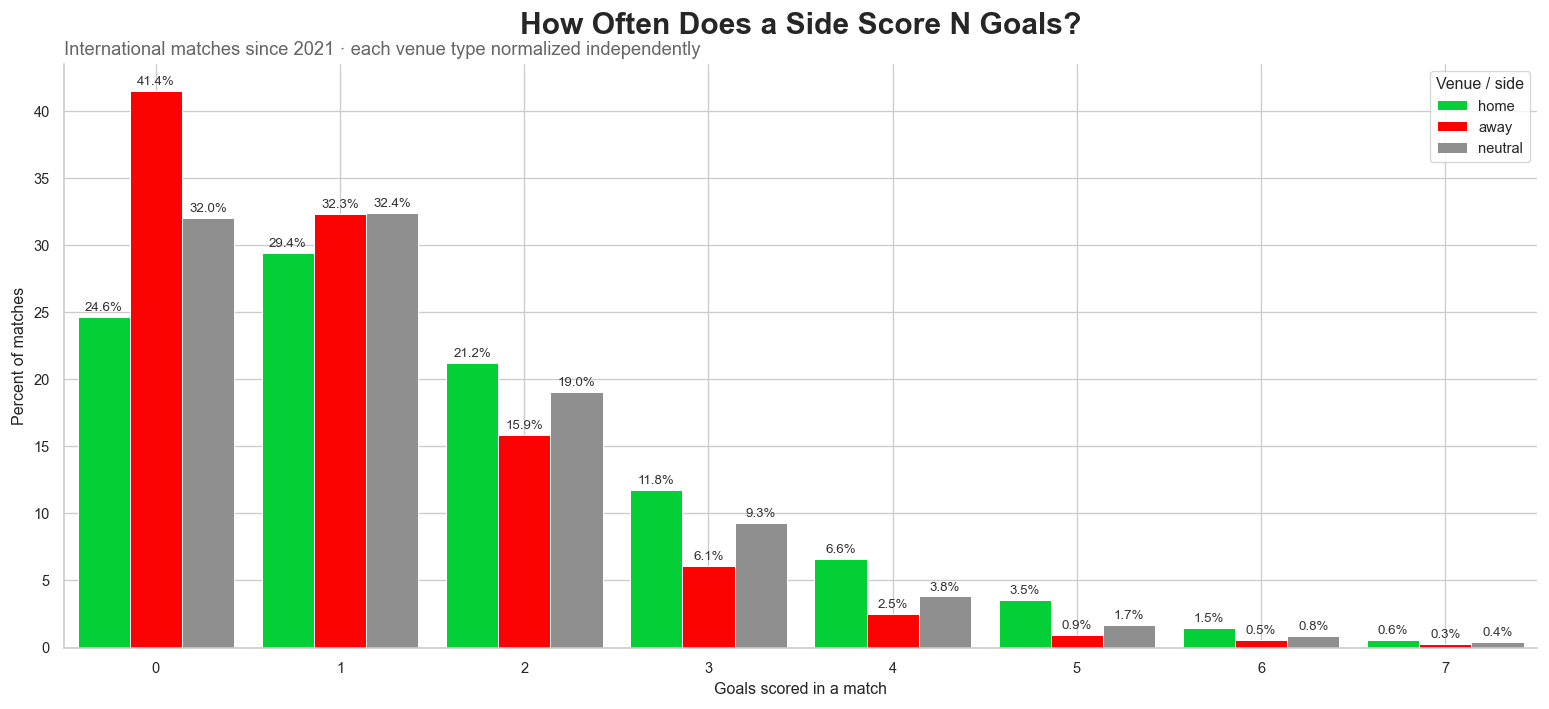

In [14]:
import scipy
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="paper")
PALETTE = {"home": "#04cf37", "away": "#fc0303", "neutral": "#8f8f8f"}


def plot_goal_distribution(overlay_poisson=False):
    """Goals-per-side histogram; optionally overlay a Poisson(λ=mean) curve.

    Builds its OWN figure every call. That's the key: Jupyter's inline backend
    renders and *closes* open figures at the end of each cell, so you can't make
    a figure in one cell and add to it in the next -- you make a fresh one here
    instead. Call with overlay_poisson=False for the raw view, True to compare
    against the model.
    """
    fig, ax = plt.subplots(figsize=(13, 6), dpi=120)

    sns.histplot(
        data=long_goals, x="goals", hue="side",
        discrete=True, multiple="dodge", shrink=0.85,
        stat="percent", common_norm=False,        # each venue type sums to 100% on its own
        palette=PALETTE, edgecolor="white", linewidth=0.6, alpha=1.0,   # solid bars
        hue_order=["home", "away", "neutral"], ax=ax,
    )

    # annotate each bar with its percentage — a static stand-in for hover tips
    for bars in ax.containers:
        ax.bar_label(bars, fmt="%.1f%%", padding=2, fontsize=8, color="#333")

    ax.set_xlim(-0.5, 7.5)          # crop the rare blowout tail so the bars get width
    ax.set_xticks(range(0, 8))
    ax.set_xlabel("Goals scored in a match")
    ax.set_ylabel("Percent of matches")
    ax.set_title("How Often Does a Side Score N Goals?", fontsize=18, weight="bold", pad=18)
    ax.text(0.0, 1.015,
            "International matches since 2021 · each venue type normalized independently",
            transform=ax.transAxes, fontsize=11, color="#666")
    ax.get_legend().set_title("Venue / side")   # seaborn already made the legend; just retitle
    sns.despine()

    if overlay_poisson:
        # lambda = each side's mean goals; k = goal counts 0..7 (x AND pmf input).
        # *100 -> percent so the curve lands on the same axis as the bars.
        k = np.arange(0, 8)
        lambdas = long_goals.groupby("side")["goals"].mean()
        for side, colour in PALETTE.items():
            pmf = scipy.stats.poisson.pmf(k, lambdas[side]) * 100
            ax.plot(k, pmf, "o--", color=colour, markeredgecolor="black", linewidth=1)

    plt.tight_layout()
    plt.show()


# attempt 1 — observed distribution only
plot_goal_distribution(overlay_poisson=False)


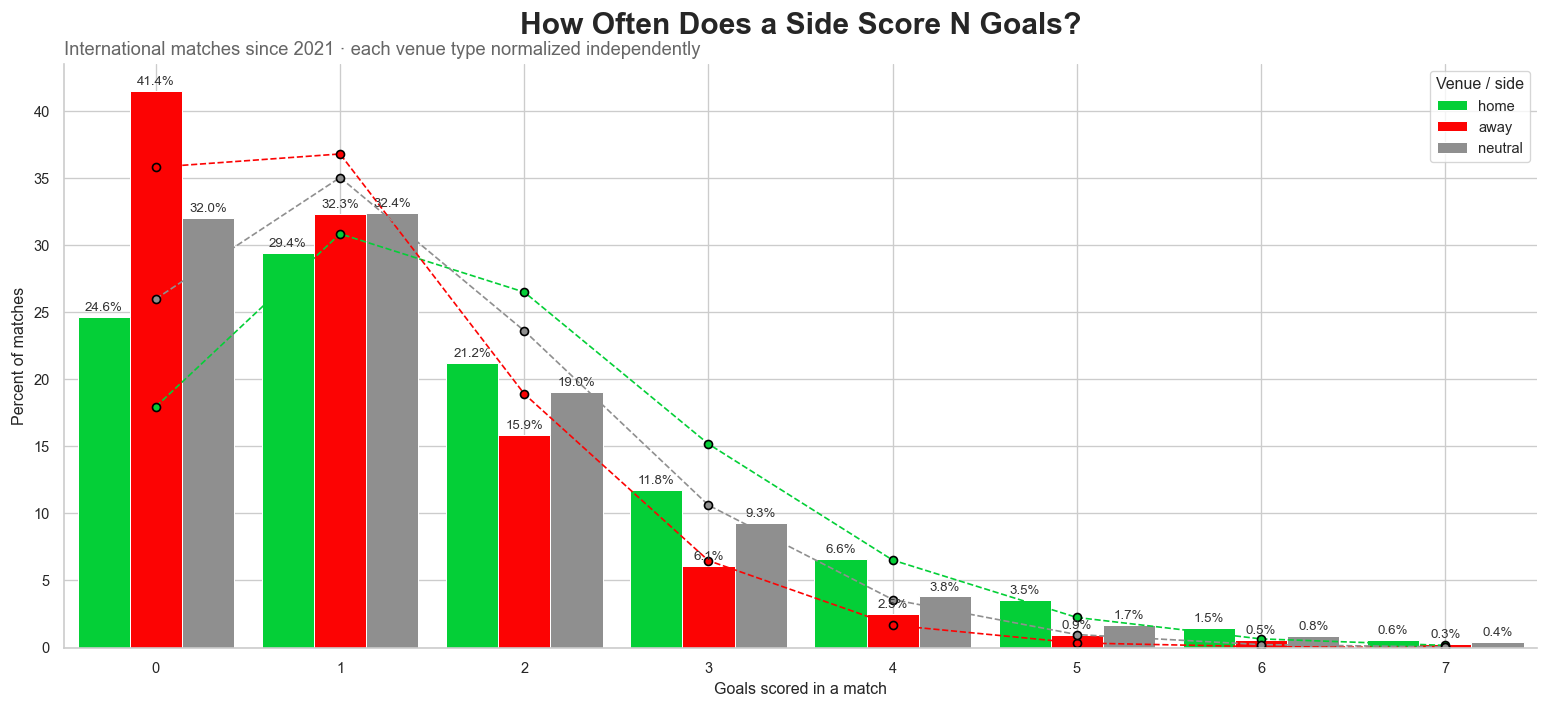

In [15]:
# attempt 2 — same distribution, now with the Poisson(λ = side mean) overlay.
# fresh figure (built inside the function), so this renders on its own.
plot_goal_distribution(overlay_poisson=True)


In [16]:
# IS THE GOAL COUNT ~POISSON?  The eye can't see dispersion, so test it.
# A true Poisson has variance == mean, so the ratio var/mean ("dispersion
# index") should sit near 1. We check the two things our two models will
# each predict -- home goals and away goals -- plus neutral for reference.
# (Same home/away/neutral split as the histogram above.)
played = df.dropna(subset=["home_score", "away_score"])

checks = {
    "home goals":    played.loc[~played["neutral"], "home_score"].astype(int),
    "away goals":    played.loc[~played["neutral"], "away_score"].astype(int),
    "neutral goals": pd.concat([played.loc[played["neutral"], "home_score"],
                                played.loc[played["neutral"], "away_score"]]).astype(int),
}

report = pd.DataFrame({
    name: {"n": g.size,
           "mean (λ)": g.mean(),
           "variance": g.var(),
           "var/mean": g.var() / g.mean()}     # ~1.0 == Poisson-consistent
    for name, g in checks.items()
}).T.round(3)

report

,n,mean (λ),variance,var/mean
home goals,3726.0,1.718,2.745,1.598
away goals,3726.0,1.028,1.478,1.438
neutral goals,3838.0,1.348,2.074,1.539


<Axes: title={'center': 'Probability of Score Results Home/Away'}, xlabel='away_score', ylabel='home_score'>

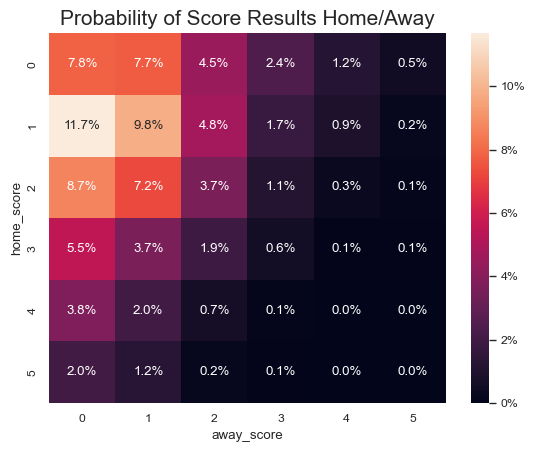

In [17]:
from matplotlib.ticker import PercentFormatter

home_away_df = df[df['neutral'] == False]
grid = pd.crosstab(home_away_df['home_score'], home_away_df['away_score'], normalize=True)
grid_cropped = grid.loc[:5, :5]

heatmap = sns.heatmap(grid_cropped, annot=True, fmt=".1%", cmap="rocket", cbar_kws={"format": PercentFormatter(xmax=1, decimals=0)})
heatmap.set_title("Probability of Score Results Home/Away").set_fontsize(15)
heatmap

<Axes: title={'center': 'Probability of Score Results Home/Away'}, xlabel='away_score', ylabel='home_score'>

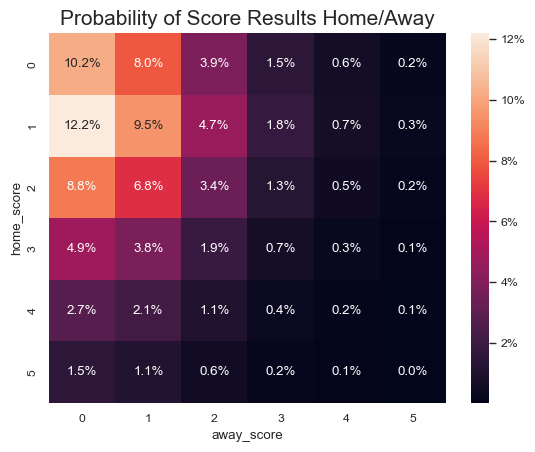

In [18]:
p_home = grid.sum(axis=1)
p_away = grid.sum(axis=0)

independent_grid = pd.DataFrame(np.outer(p_home, p_away),index=grid.index, columns=grid.columns)
independent_grid_cropped = independent_grid.loc[:5, :5]
heatmap = sns.heatmap(independent_grid_cropped, annot=True, fmt=".1%", cmap="rocket", cbar_kws={"format": PercentFormatter(xmax=1, decimals=0)})
heatmap.set_title("Probability of Score Results Home/Away").set_fontsize(15)
heatmap

<Axes: title={'center': 'Difference in Scoreline Probability Independent vs Actual'}, xlabel='away_score', ylabel='home_score'>

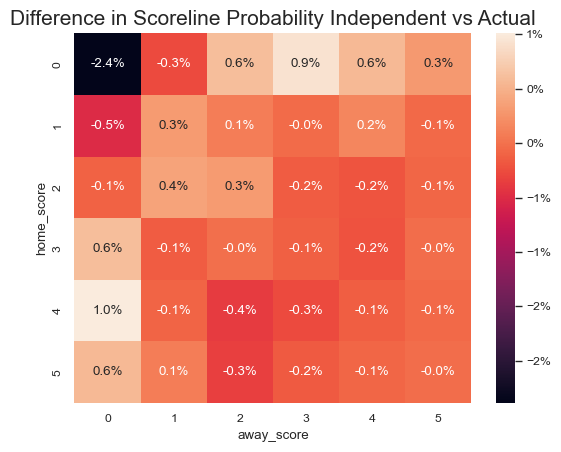

In [19]:
difference_grid = grid - independent_grid
difference_grid_cropped = difference_grid.loc[:5, :5]

heatmap = sns.heatmap(difference_grid_cropped, annot=True, fmt=".1%", cmap="rocket", cbar_kws={"format": PercentFormatter(xmax=1, decimals=0)})
heatmap.set_title("Difference in Scoreline Probability Independent vs Actual").set_fontsize(15)
heatmap

matches in slice: 806


<Axes: title={'center': 'Difference in Scoreline Probability Independent vs Actual Similar Elo'}, xlabel='away_score', ylabel='home_score'>

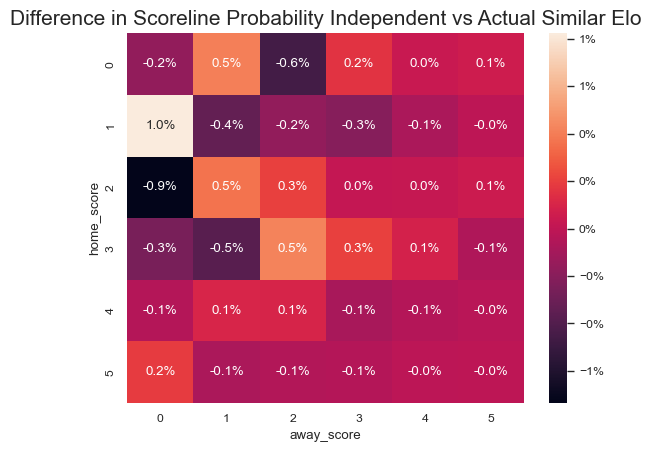

In [20]:
# 1. keep only home/away games that are also ELO-balanced
gap = (home_away_df["elo_home_pre"] - home_away_df["elo_away_pre"]).abs()
even = home_away_df[gap < 75]          # try 50; loosen to 75/100 if n gets too small

# 2. rebuild observed + independence grids on this slice
grid_even = pd.crosstab(even["home_score"], even["away_score"], normalize=True)
p_home = grid_even.sum(axis=1)
p_away = grid_even.sum(axis=0)
indep_even = pd.DataFrame(np.outer(p_home, p_away),
                        index=grid_even.index, columns=grid_even.columns)

# 3. the diff to plot
diff_even = grid_even - indep_even
print("matches in slice:", len(even))
heatmap = sns.heatmap(diff_even.loc[:5, :5], annot=True, fmt=".1%", cmap="rocket", cbar_kws={"format": PercentFormatter(xmax=1, decimals=0)})
heatmap.set_title("Difference in Scoreline Probability Independent vs Actual Similar Elo").set_fontsize(15)
heatmap


<Axes: title={'center': 'Probability of Score Results Neutral Games'}, xlabel='team_b_score', ylabel='team_a_score'>

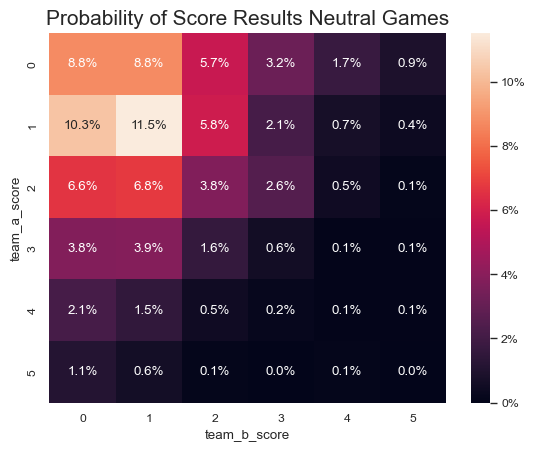

In [21]:
neutral_df = df[df['neutral'] == True]
neutral_df.rename(columns={'home_score': 'team_a_score', 'away_score': 'team_b_score'}, inplace=True)
grid = pd.crosstab(neutral_df['team_a_score'], neutral_df['team_b_score'], normalize=True)
grid = grid.loc[:5, :5]

heatmap = sns.heatmap(grid, annot=True, fmt=".1%", cmap="rocket", cbar_kws={"format": PercentFormatter(xmax=1, decimals=0)})
heatmap.set_title("Probability of Score Results Neutral Games").set_fontsize(15)
heatmap

<Axes: title={'center': 'Probability of Score Results Neutral Games'}, xlabel='team_b_score', ylabel='team_a_score'>

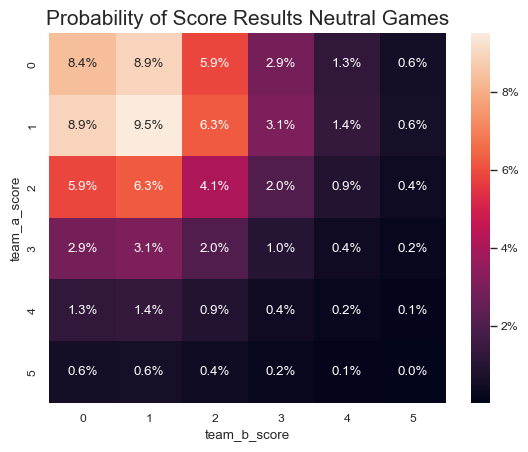

In [22]:
p_a = grid.sum(axis=1)
p_b = grid.sum(axis=0)
neutral_independent = pd.DataFrame(np.outer(p_a, p_a),index=grid.index, columns=grid.columns)
neutral_independent_cropped = neutral_independent.loc[:5, :5]
heatmap = sns.heatmap(neutral_independent_cropped, annot=True, fmt=".1%", cmap="rocket", cbar_kws={"format": PercentFormatter(xmax=1, decimals=0)})
heatmap.set_title("Probability of Score Results Neutral Games").set_fontsize(15)
heatmap

<Axes: title={'center': 'Difference in Scoreline Probability Independent vs Actual'}, xlabel='team_b_score', ylabel='team_a_score'>

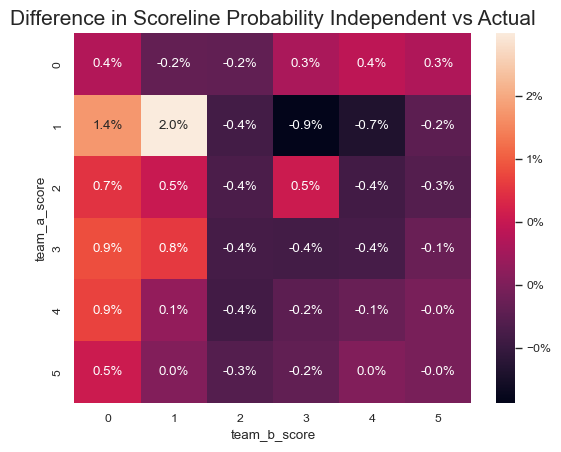

In [23]:
difference_grid = grid - neutral_independent
difference_grid_cropped = difference_grid.loc[:5, :5]

heatmap = sns.heatmap(difference_grid_cropped, annot=True, fmt=".1%", cmap="rocket", cbar_kws={"format": PercentFormatter(xmax=1, decimals=0)})
heatmap.set_title("Difference in Scoreline Probability Independent vs Actual").set_fontsize(15)
heatmap

#### Cluster Map
This graph normalizes 6 metrics for teams overall, attack, midfield, defence, starting_xi_avg_age, and ELO where + is above average and - below. The result is a clustermap that cluster teams of similar stats together to show how similar or different teams are.

teams in clustermap: 48 / 48


Text(0.5, 1.0, '2026 World Cup teams clustered by FC26 ratings + ELO')

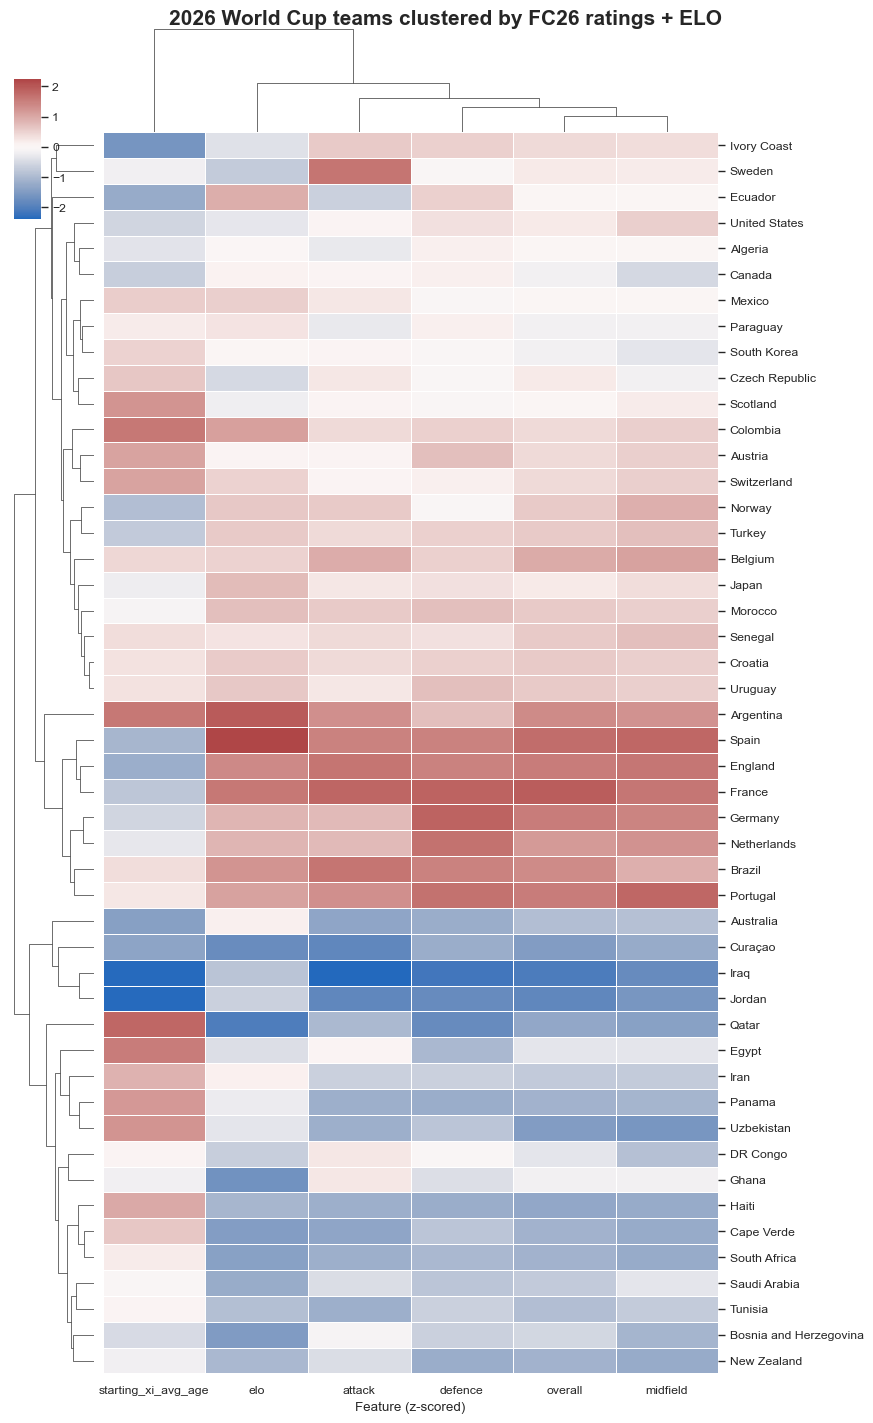

In [24]:
# Cluster the 48 World Cup teams into "tiers" by their FC26 ratings + final ELO.
# NOTE: if this errors with "clustermap requires scipy", just restart the
# kernel — seaborn caches the scipy check at import time, and this kernel
# first imported seaborn before scipy was installed.

# one row per team: latest snapshot (year 2026) + final ELO
latest_26 = (team_stats[team_stats['year'] == 2026]
             .set_index('team')[['overall', 'attack', 'midfield',
                                  'defence', 'starting_xi_avg_age']])
latest_26['elo'] = pd.Series(final_ratings)

# restrict to the 48 WC participants
team_matrix = latest_26.loc[latest_26.index.isin(WC_2026_TEAMS)].dropna()
print(f"teams in clustermap: {len(team_matrix)} / 48")

g = sns.clustermap(
    team_matrix,
    z_score=1,                 # standardize each col
    cmap="vlag", center=0,
    figsize=(9, 14),
    dendrogram_ratio=(0.12, 0.08),
    cbar_pos=(0.02, 0.85, 0.03, 0.10),
    linewidths=0.4,
)
g.ax_heatmap.set_xlabel("Feature (z-scored)")
g.ax_heatmap.set_ylabel("")
g.figure.suptitle("2026 World Cup teams clustered by FC26 ratings + ELO",
                  y=1.0, fontsize=15, weight="bold")


### Tournament Stats

In [25]:
# tournament groupings
# 200 distinct tournament strings collapse into 5 readable buckets.
# "Continental Cups" has no common substring across confederations, so the
# senior championships are listed explicitly; the other 4 buckets are rules,
# so any future/unseen tournament string still classifies (-> "Other").
CONTINENTAL_CUPS = {
    'UEFA Euro', 'UEFA Nations League',                              # UEFA
    'Copa América',                                                  # CONMEBOL
    'African Cup of Nations',                                        # CAF
    'AFC Asian Cup',                                                 # AFC
    'Gold Cup', 'CONCACAF Championship', 'CONCACAF Nations League',  # CONCACAF
    'Oceania Nations Cup',                                           # OFC
}

def tournament_group(t: str) -> str:
    """Map a raw `tournament` string to one of 5 analysis buckets."""
    if 'qualification' in t:           # WC/Euro/AFCON/... qualifiers (check first)
        return 'Qualifiers'
    if t == 'FIFA World Cup':
        return 'World Cup'
    if t in CONTINENTAL_CUPS:
        return 'Continental Cups'
    if t == 'Friendly':
        return 'Friendlies'
    return 'Other'

# attach to the frame for the by-tournament plots
tourny_df = df.copy()
tourny_df['tournament_group'] = tourny_df['tournament'].map(tournament_group)
tourny_df['tournament_group'].value_counts()

tournament_group
Qualifiers          2359
Friendlies          1455
Continental Cups    1149
Other                618
World Cup            136
Name: count, dtype: int64

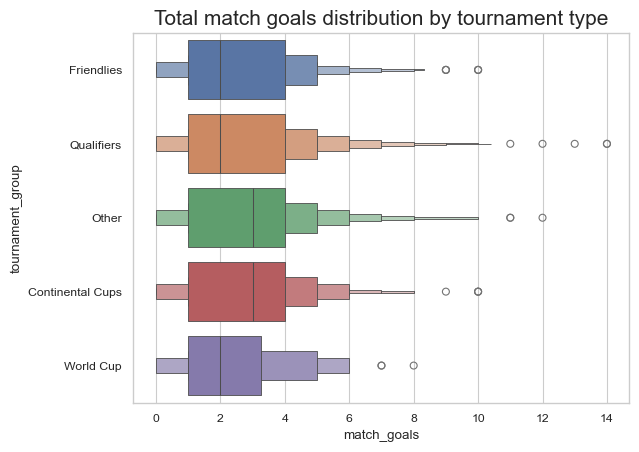

In [26]:
tourny_df['match_goals'] = tourny_df['home_score'] + tourny_df['away_score']
boxplot = sns.boxenplot(x="match_goals", y="tournament_group", data=tourny_df, hue="tournament_group")
boxplot.set_title("Total match goals distribution by tournament type").set_fontsize(15)

Text(0, 0.5, '')

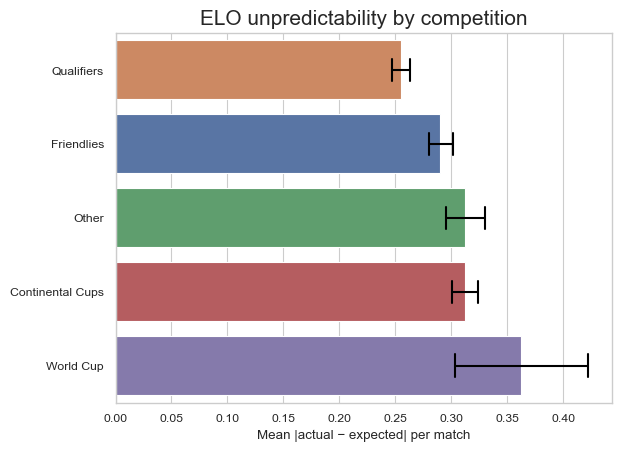

In [27]:
# Unpredictability index for ONE match = |actual - expected|, in [0, 1].
#   expected : ELO's pre-match win-expectancy for the home side. Reuses the
#              same `expected_score` from the ELO cell, so home advantage (100)
#              and neutral sites (0) are handled exactly as they were when the
#              ratings were built -- no drift between the two definitions.
#   actual   : 1.0 win / 0.5 draw / 0.0 loss, from the home side's POV.
# 0  -> chalk: the favourite did exactly what ELO expected.
# ~1 -> shock: a near-certain side got the opposite result.
# NaN for unplayed matches (the 2026 fixtures), so they drop out of any groupby.

def unpredictability(row) -> float:
    if pd.isna(row.home_score) or pd.isna(row.away_score):
        return np.nan

    home_adv = 0.0 if row.neutral else 100.0
    exp_home = expected_score(row.elo_home_pre, row.elo_away_pre, home_adv)

    if row.home_score > row.away_score:
        actual_home = 1.0
    elif row.home_score < row.away_score:
        actual_home = 0.0
    else:
        actual_home = 0.5

    return abs(actual_home - exp_home)



tourny_df["unpredictability"] = tourny_df.apply(unpredictability, axis=1)
tourny_unpredictability = tourny_df.groupby("tournament_group")["unpredictability"].mean()
order = tourny_unpredictability.sort_values().index

ax = sns.barplot(
  data=tourny_df,
  x="unpredictability", y="tournament_group",
  order=order, hue="tournament_group", legend=False,
  errorbar=("ci", 95),
  capsize=0.3,
  err_kws={"linewidth": 1.5, "color": "black"},
)

ax.set_title("ELO unpredictability by competition").set_fontsize(15)
ax.set_xlabel("Mean |actual − expected| per match")
ax.set_ylabel("")


**Do heavy favorites get upset more often in certain tournaments?** Probably not/Inconclusive

                       n  upset_rate  mean_fav_strength
fav_bin                                                
toss-up\n(.50-.60)  1102       0.595              0.551
slight\n(.60-.75)   1684       0.495              0.675
clear\n(.75-.90)    1784       0.322              0.827
heavy\n(.90-1.0)    1075       0.125              0.945


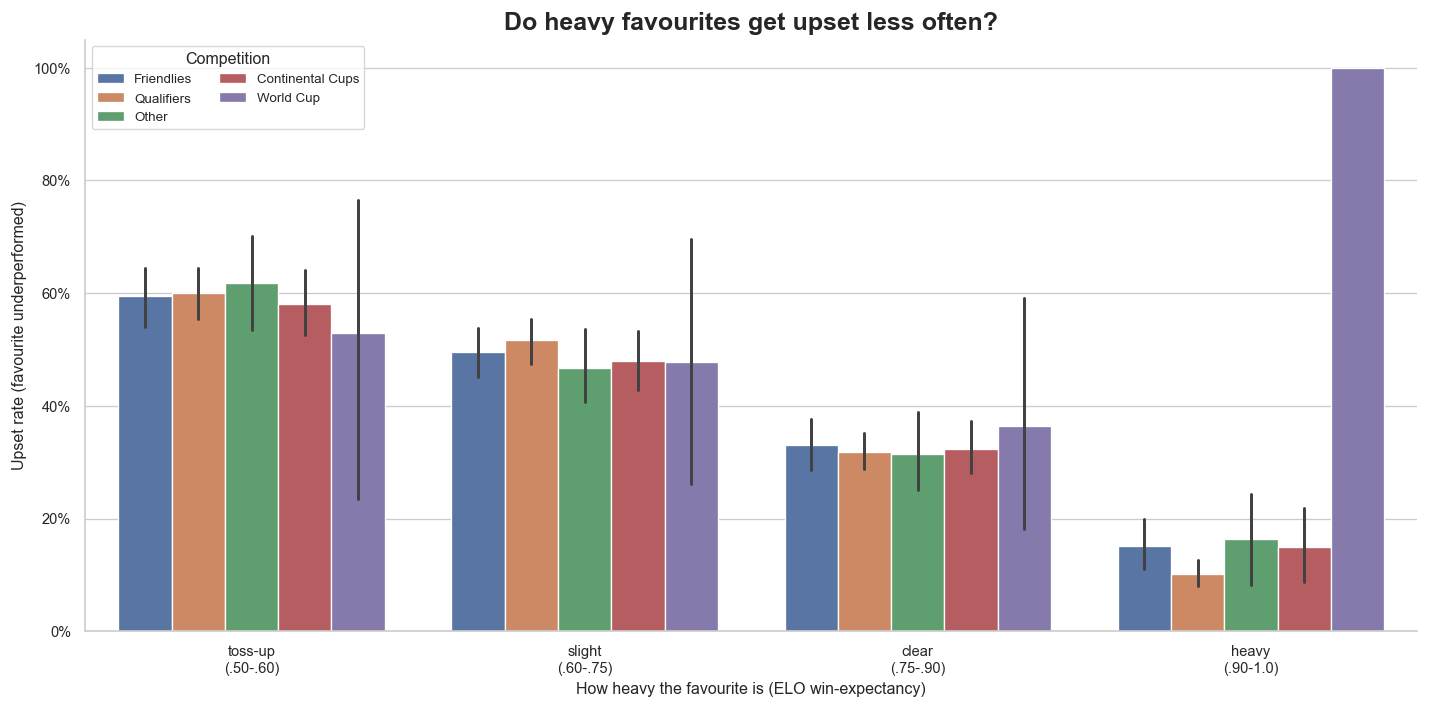

In [28]:
# This one I just let Claude make for the hell of it, think the sample size is a bit weak especially for WC
# Heavy vs slight favourites: does an upset get less likely as the favourite
# gets stronger -- and does that pattern differ by competition?
from matplotlib.ticker import PercentFormatter   # (safe to re-import)

# Per match, vectorised, using the SAME ELO expectation as everywhere else:
#   exp_home     : home win-expectancy (points share, draw counts 0.5)
#   fav_strength : max(exp_home, 1 - exp_home) in [0.5, 1] -- how heavy the fav is
#   fav_surprise : favourite's (actual - expected); < 0 = favourite underperformed
#   is_upset     : 1 when fav_surprise < 0 (favourite failed to meet expectation)
played = tourny_df.dropna(subset=["home_score", "away_score"]).copy()

home_adv = np.where(played["neutral"], 0.0, 100.0)
exp_home = 1.0 / (1.0 + 10.0 ** (
    -(played["elo_home_pre"] - played["elo_away_pre"] + home_adv) / 400.0))

hs, ascore = played["home_score"].astype(int), played["away_score"].astype(int)
actual_home = np.where(hs > ascore, 1.0, np.where(hs < ascore, 0.0, 0.5))

home_is_fav = exp_home >= 0.5
fav_strength = np.maximum(exp_home, 1.0 - exp_home)
fav_surprise = np.where(home_is_fav, actual_home - exp_home, exp_home - actual_home)

played["fav_strength"] = fav_strength
played["is_upset"] = (fav_surprise < 0).astype(int)
played["fav_bin"] = pd.cut(
    fav_strength,
    bins=[0.50, 0.60, 0.75, 0.90, 1.01],
    labels=["toss-up\n(.50-.60)", "slight\n(.60-.75)",
            "clear\n(.75-.90)", "heavy\n(.90-1.0)"],
    include_lowest=True,
)

# headline numbers, overall
summary = (played.groupby("fav_bin", observed=True)
           .agg(n=("is_upset", "size"),
                upset_rate=("is_upset", "mean"),
                mean_fav_strength=("fav_strength", "mean"))
           .round(3))
print(summary)

# Chart: upset rate by favourite strength, split by competition.
# y is the mean of a 0/1 column -> the upset rate; seaborn adds 95% bootstrap
# CIs, which keep us honest about the thin cells (World Cup especially).
fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
sns.barplot(data=played, x="fav_bin", y="is_upset",
            hue="tournament_group", errorbar=("ci", 95), ax=ax)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_xlabel("How heavy the favourite is (ELO win-expectancy)")
ax.set_ylabel("Upset rate (favourite underperformed)")
ax.set_title("Do heavy favourites get upset less often?", fontsize=15, weight="bold")
ax.legend(title="Competition", fontsize=8, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()


## Deciding on a model

In [29]:
df_with_stats.corr(numeric_only=True)

,home_score,away_score,neutral,elo_home_pre,elo_away_pre,gf_home_recent,ga_home_recent,gf_away_recent,ga_away_recent,wdl_home_recent,...,home_overall,home_attack,home_midfield,home_defence,home_starting_xi_avg_age,away_overall,away_attack,away_midfield,away_defence,away_starting_xi_avg_age
home_score,1.000000,-0.207225,-0.090403,0.210439,-0.281456,0.234791,-0.051423,-0.191699,0.118156,0.171434,...,0.178742,0.161204,0.183651,0.166434,-0.080231,-0.152282,-0.150908,-0.145857,-0.142089,-0.047959
away_score,-0.207225,1.000000,0.092688,-0.284487,0.182127,-0.190120,0.177207,0.201780,-0.012555,-0.192055,...,-0.063185,-0.065119,-0.051435,-0.073545,-0.033022,0.202025,0.191792,0.196635,0.195859,-0.114108
neutral,-0.090403,0.092688,1.000000,-0.042484,0.009983,-0.055415,-0.001464,0.004563,-0.039096,-0.025755,...,0.008856,0.043754,0.006346,0.007049,0.082179,-0.042818,-0.023725,-0.040085,-0.040249,0.026227
elo_home_pre,0.210439,-0.284487,-0.042484,1.000000,0.514155,0.693838,-0.098990,0.320176,-0.013535,0.543387,...,0.851472,0.788342,0.830533,0.818636,-0.138985,0.175259,0.156403,0.166267,0.179212,-0.019024
elo_away_pre,-0.281456,0.182127,0.009983,0.514155,1.000000,0.306699,0.032711,0.705549,-0.085772,0.174394,...,0.236952,0.212793,0.233703,0.236495,-0.072400,0.840890,0.771577,0.819760,0.813634,-0.083244
gf_home_recent,0.234791,-0.190120,-0.055415,0.693838,0.306699,1.000000,-0.100358,0.255952,0.006158,0.579459,...,0.538632,0.500639,0.540087,0.518883,-0.241161,0.145761,0.144157,0.135941,0.145652,-0.056998
ga_home_recent,-0.051423,0.177207,-0.001464,-0.098990,0.032711,-0.100358,1.000000,0.033794,0.142701,-0.351196,...,0.196651,0.155736,0.204558,0.172313,-0.115594,0.122087,0.096294,0.116066,0.125583,-0.067364
gf_away_recent,-0.191699,0.201780,0.004563,0.320176,0.705549,0.255952,0.033794,1.000000,-0.086520,0.144967,...,0.174330,0.152416,0.171742,0.184329,-0.108326,0.522555,0.483257,0.511463,0.496365,-0.212349
ga_away_recent,0.118156,-0.012555,-0.039096,-0.013535,-0.085772,0.006158,0.142701,-0.086520,1.000000,-0.064717,...,0.086873,0.058992,0.082506,0.094704,-0.045309,0.168419,0.147904,0.172608,0.151980,-0.089119
wdl_home_recent,0.171434,-0.192055,-0.025755,0.543387,0.174394,0.579459,-0.351196,0.144967,-0.064717,1.000000,...,0.314686,0.315274,0.306711,0.314087,-0.071147,0.046944,0.056405,0.048618,0.046005,-0.020212


#### Goals vs ELO difference

<Axes: xlabel='mid', ylabel='mean'>

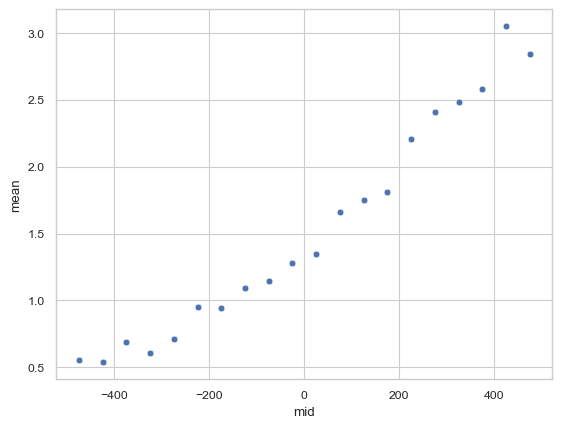

In [41]:
goals_vs_elo = df.copy()

goals_vs_elo['elo_diff'] = goals_vs_elo['elo_home_pre'] - goals_vs_elo['elo_away_pre']

bins = np.arange(-500, 501, 50)
goals_vs_elo['elo_dif_bin'] = pd.cut(goals_vs_elo['elo_diff'], bins=bins)
by_bin = goals_vs_elo.groupby("elo_dif_bin", observed=True)["home_score"].agg(["mean", "size"])
by_bin["mid"] = [iv.mid for iv in by_bin.index]

ax = sns.scatterplot(by_bin, x="mid", y="mean")
ax

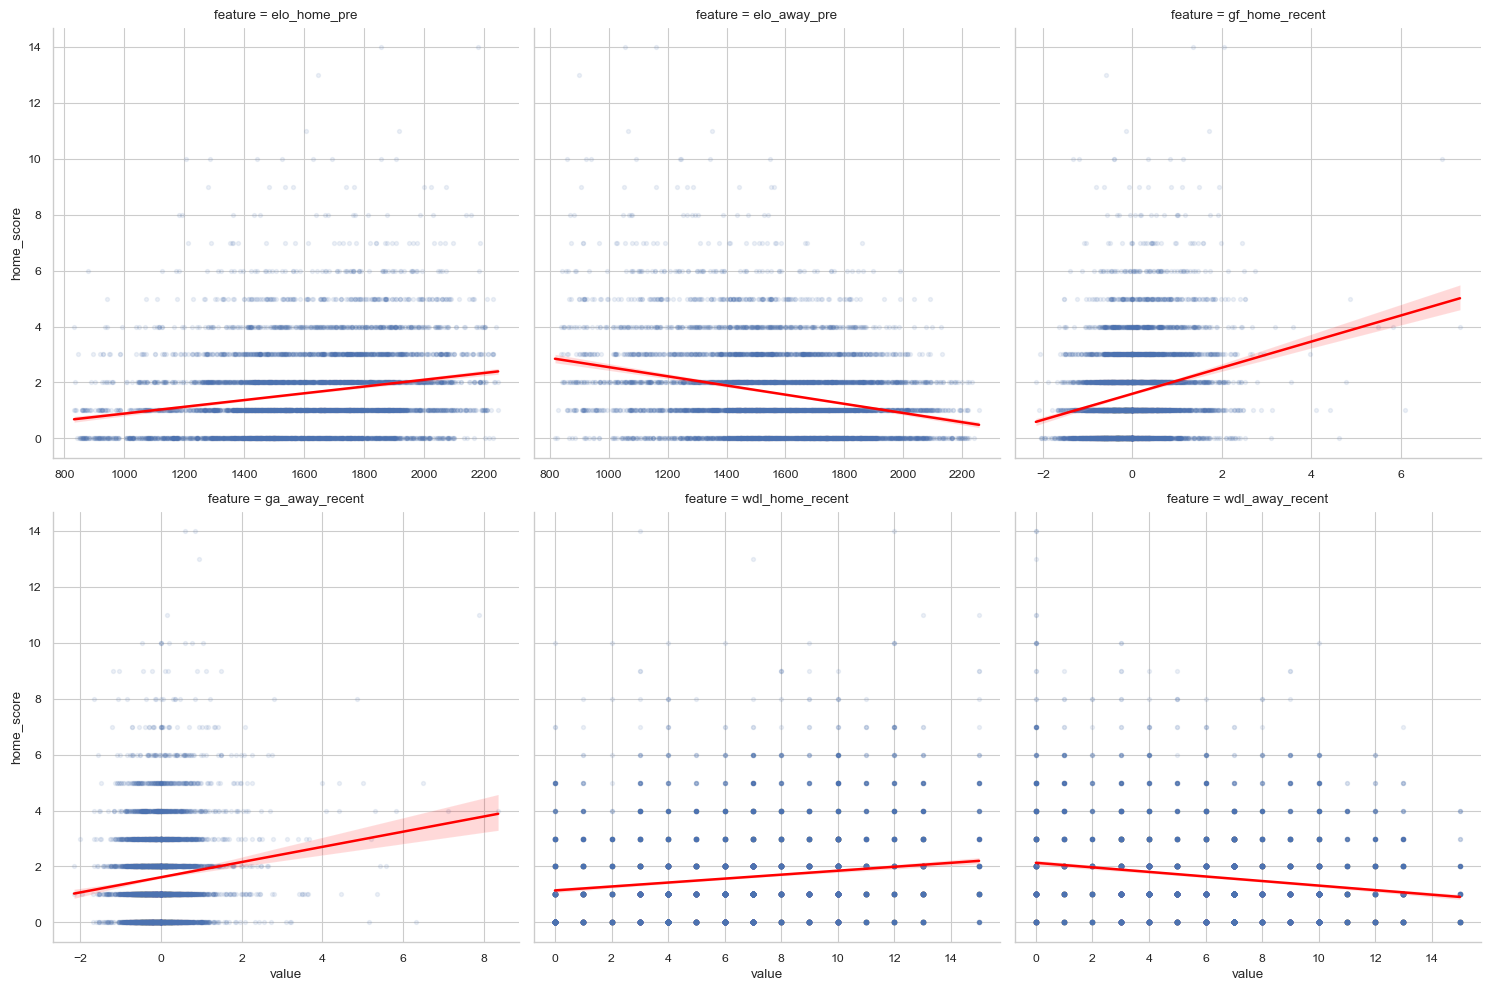

In [45]:
features = ['elo_home_pre', 'elo_away_pre', 'gf_home_recent', 'ga_away_recent', 'wdl_home_recent', 'wdl_away_recent']
long = df_with_stats.melt(id_vars="home_score", value_vars=features, var_name="feature", value_name="value").dropna(subset=["home_score", "value"])
sns.lmplot(
  data=long, x="value", y="home_score",
  col="feature", col_wrap=3,
  facet_kws={"sharex": False},   # each feature has its own x-range
  scatter_kws={"alpha": 0.1, "s": 8},
  line_kws={"color": "red"},
)
